# Fase 1 — Análisis Exploratorio del Dataset (EDA · v4)

**Proyecto:** Sistema de detección y conteo de monedas colombianas con YOLO.

**Dataset:** `COP Coin v4` (Roboflow, exportado el 2026-05-08).

**Diferencias clave frente a versiones anteriores:**
1. Imágenes **a color** (las versiones anteriores eran grayscale).
2. Anotaciones en formato **YOLO Oriented Bounding Box (OBB)**: cada línea tiene 9 tokens — `class_id  x1 y1 x2 y2 x3 y3 x4 y4` — los cuatro vértices de un cuadrilátero rotado.
3. Augmentations aplicadas en Roboflow: 9 versiones por imagen original (rotación 90° none/cw/ccw, shear ±10°/±12°, blur gaussian 0–1.2 px).
4. Pre-proceso: resize a 512×512 con **stretch** (sin preservar proporciones).

**Objetivo del notebook:** caracterizar el dataset, validar formato OBB, detectar redundancias por augmentation y producir los hallazgos que alimentarán la Fase 2 (entrenamiento).

## 1. Imports y configuración

In [1]:
from __future__ import annotations
import re, random
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
import yaml
from PIL import Image

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
random.seed(42); np.random.seed(42)

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATASET = ROOT / "dataset"
REPORTS = ROOT / "reports"; REPORTS.mkdir(exist_ok=True)

print(f"ROOT    = {ROOT}")
print(f"DATASET = {DATASET}")

ROOT    = /Users/ccepeda/Documents/Personales/Maestria/SistemaRecomendacion
DATASET = /Users/ccepeda/Documents/Personales/Maestria/SistemaRecomendacion/dataset


## 2. Carga de `data.yaml` y mapeo de clases

Esta versión usa el formato moderno de Ultralytics: `names:` como diccionario `{id: nombre}` en vez de lista.

In [2]:
with open(DATASET / "data.yaml") as f:
    data_cfg = yaml.safe_load(f)

# Soportar tanto names dict (v4) como lista (versiones previas)
raw_names = data_cfg["names"]
if isinstance(raw_names, dict):
    ID2NAME = {int(k): str(v) for k, v in raw_names.items()}
else:
    ID2NAME = {i: str(n) for i, n in enumerate(raw_names)}
NC = len(ID2NAME)

VALUE_COP = {cid: (int(name) if name.isdigit() else 0) for cid, name in ID2NAME.items()}

print(f"nc = {NC}")
for cid, name in sorted(ID2NAME.items()):
    print(f"  {cid} -> {name!r:6s}  valor = {VALUE_COP[cid]} COP")
data_cfg

nc = 5
  0 -> '100'   valor = 100 COP
  1 -> '1000'  valor = 1000 COP
  2 -> '200'   valor = 200 COP
  3 -> '50'    valor = 50 COP
  4 -> '500'   valor = 500 COP


{'train': 'train/images',
 'val': 'valid/images',
 'test': 'test/images',
 'names': {0: 100, 1: 1000, 2: 200, 3: 50, 4: 500}}

## 3. Inventario de archivos por split

In [3]:
SPLITS = ["train", "valid", "test"]
IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

def list_images(split: str) -> list[Path]:
    d = DATASET / split / "images"
    return sorted([p for p in d.iterdir() if p.suffix.lower() in IMG_EXTS]) if d.exists() else []

def list_labels(split: str) -> list[Path]:
    d = DATASET / split / "labels"
    return sorted([p for p in d.iterdir() if p.suffix.lower() == ".txt"]) if d.exists() else []

rows = []
for split in SPLITS:
    imgs = list_images(split)
    lbls = list_labels(split)
    img_stems = {p.stem for p in imgs}
    lbl_stems = {p.stem for p in lbls}
    rows.append({
        "split": split,
        "images": len(imgs),
        "labels": len(lbls),
        "emparejados": len(img_stems & lbl_stems),
        "img_sin_label": len(img_stems - lbl_stems),
        "label_sin_img": len(lbl_stems - img_stems),
    })

df_inv = pd.DataFrame(rows).set_index("split")
df_inv.to_csv(REPORTS / "inventory.csv")
df_inv

,images,labels,emparejados,img_sin_label,label_sin_img
split,,,,,
train,198,198,198,0,0
valid,8,8,8,0,0
test,8,8,8,0,0


## 4. Lectura de anotaciones OBB y conversión a bbox

Cada anotación tiene 9 tokens: `class_id` + 4 vértices (x,y) normalizados al rango `[0,1]`.

Para análisis posterior calculamos dos representaciones:
- **AABB** (axis-aligned bounding box): `min/max` de los vértices → la caja que YOLOv8-detect espera.
- **OBB nativo**: ancho y alto del cuadrilátero en su sistema de coordenadas rotado, usando distancias entre vértices consecutivos. Útil para conocer el aspect ratio real de la moneda independientemente de la rotación.

In [4]:
def parse_obb_file(path: Path) -> list[dict]:
    out = []
    if not path.exists():
        return out
    for line_no, raw in enumerate(path.read_text().splitlines(), start=1):
        t = raw.strip().split()
        if not t:
            continue
        if len(t) != 9:
            print(f"  ⚠️  {path.name}:{line_no} tiene {len(t)} tokens (se esperaban 9) — se descarta")
            continue
        cid = int(t[0])
        coords = np.array(list(map(float, t[1:])), dtype=float).reshape(4, 2)
        # AABB
        xs, ys = coords[:, 0], coords[:, 1]
        x_min, y_min = xs.min(), ys.min()
        x_max, y_max = xs.max(), ys.max()
        # OBB nativo: lados consecutivos del cuadrilátero (12, 23)
        side1 = np.linalg.norm(coords[1] - coords[0])
        side2 = np.linalg.norm(coords[2] - coords[1])
        obb_w, obb_h = max(side1, side2), min(side1, side2)
        # Ángulo del lado más largo respecto al eje X (en grados)
        long_edge = (coords[1] - coords[0]) if side1 >= side2 else (coords[2] - coords[1])
        angle = float(np.degrees(np.arctan2(long_edge[1], long_edge[0])))
        out.append({
            "class_id": cid,
            "vertices": coords,
            "aabb_xmin": x_min, "aabb_ymin": y_min,
            "aabb_xmax": x_max, "aabb_ymax": y_max,
            "aabb_w": x_max - x_min, "aabb_h": y_max - y_min,
            "obb_w": obb_w, "obb_h": obb_h,
            "angle_deg": angle,
        })
    return out

records = []
for split in SPLITS:
    for lbl in list_labels(split):
        for b in parse_obb_file(lbl):
            records.append({
                "split": split,
                "image_stem": lbl.stem,
                "class_id": b["class_id"],
                "class_name": ID2NAME[b["class_id"]],
                "aabb_w": b["aabb_w"], "aabb_h": b["aabb_h"],
                "obb_w": b["obb_w"], "obb_h": b["obb_h"],
                "obb_aspect": b["obb_w"] / b["obb_h"] if b["obb_h"] > 0 else np.nan,
                "angle_deg": b["angle_deg"],
            })

df = pd.DataFrame.from_records(records)
print(f"Total de anotaciones OBB: {len(df)}")
df.head()

Total de anotaciones OBB: 574


,split,image_stem,class_id,class_name,aabb_w,aabb_h,obb_w,obb_h,obb_aspect,angle_deg
0,train,IMG_5838_jpg.rf.294970e7ad5a1621586429bf292269c7,4,500,0.122074,0.168173,0.168083,0.121950,1.378290,90.042332
1,train,IMG_5838_jpg.rf.294970e7ad5a1621586429bf292269c7,4,500,0.123352,0.166136,0.160988,0.116102,1.386613,-92.624548
2,train,IMG_5838_jpg.rf.294970e7ad5a1621586429bf292269c7,4,500,0.124379,0.167524,0.161975,0.116534,1.389935,-92.826352
3,train,IMG_5838_jpg.rf.294970e7ad5a1621586429bf292269c7,4,500,0.123587,0.167517,0.162940,0.117131,1.391093,-92.304220
4,train,IMG_5838_jpg.rf.294970e7ad5a1621586429bf292269c7,4,500,0.165144,0.191039,0.165364,0.130454,1.267604,103.364185


## 5. Distribución de clases por split

In [5]:
pivot = (df.groupby(["class_id", "class_name", "split"]).size()
           .unstack("split", fill_value=0)
           .reindex(columns=SPLITS, fill_value=0))
pivot["total"] = pivot.sum(axis=1)
pivot.loc["TOTAL"] = pivot.sum(numeric_only=True)
pivot.to_csv(REPORTS / "class_distribution.csv")
pivot

split,train,valid,test,total
"(0, 100)",135,3,1,139
"(1, 1000)",99,1,1,101
"(2, 200)",108,1,2,111
"(3, 50)",72,1,2,75
"(4, 500)",144,2,2,148
TOTAL,558,8,8,574


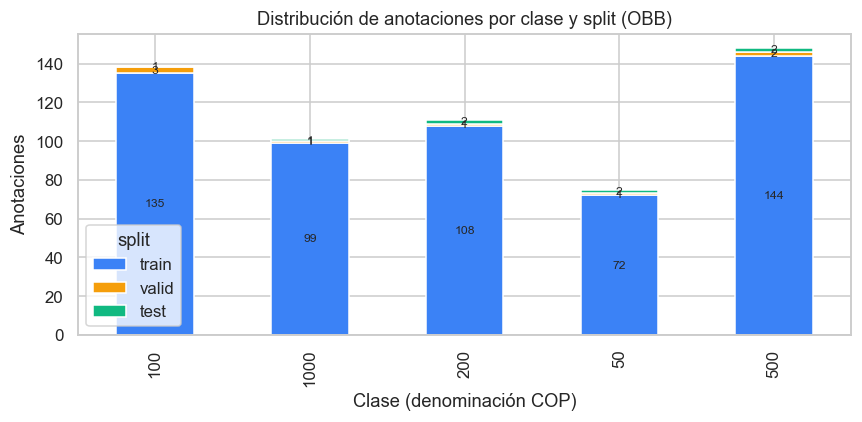

In [6]:
plot_df = (df.groupby(["class_name", "split"]).size()
             .unstack("split", fill_value=0)
             .reindex(columns=SPLITS, fill_value=0))
ax = plot_df.plot(kind="bar", stacked=True, figsize=(8, 4),
                  color=["#3b82f6", "#f59e0b", "#10b981"])
ax.set_title("Distribución de anotaciones por clase y split (OBB)")
ax.set_ylabel("Anotaciones")
ax.set_xlabel("Clase (denominación COP)")
for c in ax.containers:
    ax.bar_label(c, label_type="center", fontsize=8)
plt.tight_layout()
plt.savefig(REPORTS / "class_distribution.png", dpi=130)
plt.show()

## 6. Análisis de augmentations: imágenes únicas vs. variantes

Roboflow generó **9 versiones por imagen original**. Detectamos las imágenes únicas extrayendo el ID base del nombre (`IMG_5XXX_*` → `IMG_5XXX`) y reportamos:
- Cuántas imágenes únicas hay realmente.
- Cuántas variantes por imagen única (debería ser ~9).
- Cómo se distribuyen las variantes entre splits.

In [7]:
BASE_RE = re.compile(r"^(IMG_\d+)")

def base_id(stem: str) -> str:
    m = BASE_RE.match(stem)
    return m.group(1) if m else stem

rows = []
for split in SPLITS:
    for img in list_images(split):
        rows.append({"split": split, "stem": img.stem, "base": base_id(img.stem)})
df_imgs = pd.DataFrame(rows)

n_unique = df_imgs["base"].nunique()
n_total = len(df_imgs)
print(f"Imágenes totales: {n_total}")
print(f"Imágenes únicas (por base ID): {n_unique}")
print(f"Variantes por imagen única: media = {n_total/n_unique:.2f}")

print("\nDistribución de variantes por base:")
v_counts = df_imgs["base"].value_counts()
print(v_counts.describe().round(2))

print("\n¿Hay bases que aparecen en más de un split (leakage)?")
leakage = (df_imgs.groupby("base")["split"].nunique()
             .loc[lambda s: s > 1]
             .index.tolist())
if leakage:
    print(f"  ⚠️  {len(leakage)} bases compartidas:")
    for b in leakage[:10]:
        rows_b = df_imgs[df_imgs["base"] == b]["split"].value_counts().to_dict()
        print(f"    {b}: {rows_b}")
    if len(leakage) > 10:
        print(f"    ... ({len(leakage) - 10} más)")
else:
    print("  ✅ Ningún base compartido entre splits — sin data leakage.")

Imágenes totales: 214
Imágenes únicas (por base ID): 38
Variantes por imagen única: media = 5.63

Distribución de variantes por base:
count    38.00
mean      5.63
std       4.00
min       1.00
25%       1.00
50%       9.00
75%       9.00
max       9.00
Name: count, dtype: float64

¿Hay bases que aparecen en más de un split (leakage)?
  ✅ Ningún base compartido entre splits — sin data leakage.


## 7. Geometría: aspect ratio del OBB y del AABB

- Si las monedas reales son circulares y NO hay stretch en el resize, el aspect ratio del OBB nativo (`obb_w / obb_h`) debería estar cerca de 1.
- El AABB siempre será mayor o igual al OBB en cada dimensión, y crece con la rotación.
- Si Roboflow estiró las imágenes, el OBB tendrá ratio sistemáticamente distinto de 1 (el ratio del estiramiento).

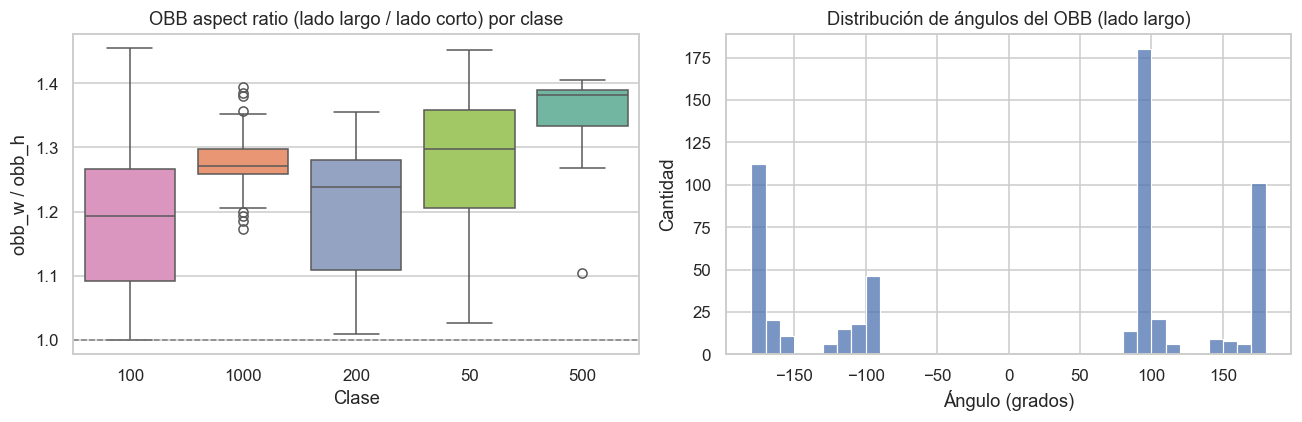


Aspect ratio del OBB:
count    574.000
mean       1.261
std        0.111
min        1.000
25%        1.198
50%        1.279
75%        1.343
max        1.455
Name: obb_aspect, dtype: float64

Aspect ratio del OBB por clase:
            count   mean  median    std
class_name                             
100           139  1.184   1.192  0.114
1000          101  1.277   1.271  0.040
200           111  1.200   1.238  0.096
50             75  1.274   1.297  0.116
500           148  1.363   1.382  0.040


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.boxplot(data=df, x="class_name", y="obb_aspect", hue="class_name",
            order=sorted(df["class_name"].unique()), ax=axes[0],
            palette="Set2", legend=False)
axes[0].axhline(1.0, ls="--", color="gray", lw=1)
axes[0].set_title("OBB aspect ratio (lado largo / lado corto) por clase")
axes[0].set_ylabel("obb_w / obb_h")
axes[0].set_xlabel("Clase")

sns.histplot(df["angle_deg"], bins=36, ax=axes[1])
axes[1].set_title("Distribución de ángulos del OBB (lado largo)")
axes[1].set_xlabel("Ángulo (grados)")
axes[1].set_ylabel("Cantidad")
plt.tight_layout()
plt.savefig(REPORTS / "obb_geometry.png", dpi=130)
plt.show()

print("\nAspect ratio del OBB:")
print(df["obb_aspect"].describe().round(3))
print("\nAspect ratio del OBB por clase:")
print(df.groupby("class_name")["obb_aspect"].agg(["count", "mean", "median", "std"]).round(3))

## 8. Anotaciones por imagen

In [9]:
bpi = df.groupby(["split", "image_stem"]).size().rename("boxes").reset_index()
summary = (bpi.groupby("split")["boxes"]
             .agg(["count", "sum", "mean", "median", "min", "max"]).round(2))
summary.columns = ["imágenes_con_boxes", "total_boxes", "media", "mediana", "mín", "máx"]
summary.to_csv(REPORTS / "boxes_per_image_summary.csv")
summary

,imágenes_con_boxes,total_boxes,media,mediana,mín,máx
split,,,,,,
test,8,8,1.00,1.0,1,1
train,198,558,2.82,1.0,1,12
valid,8,8,1.00,1.0,1,1


## 9. Visualización de muestras con OBB dibujados

Dibujamos los cuadriláteros rotados (no las AABB) para ver fielmente las anotaciones del dataset.

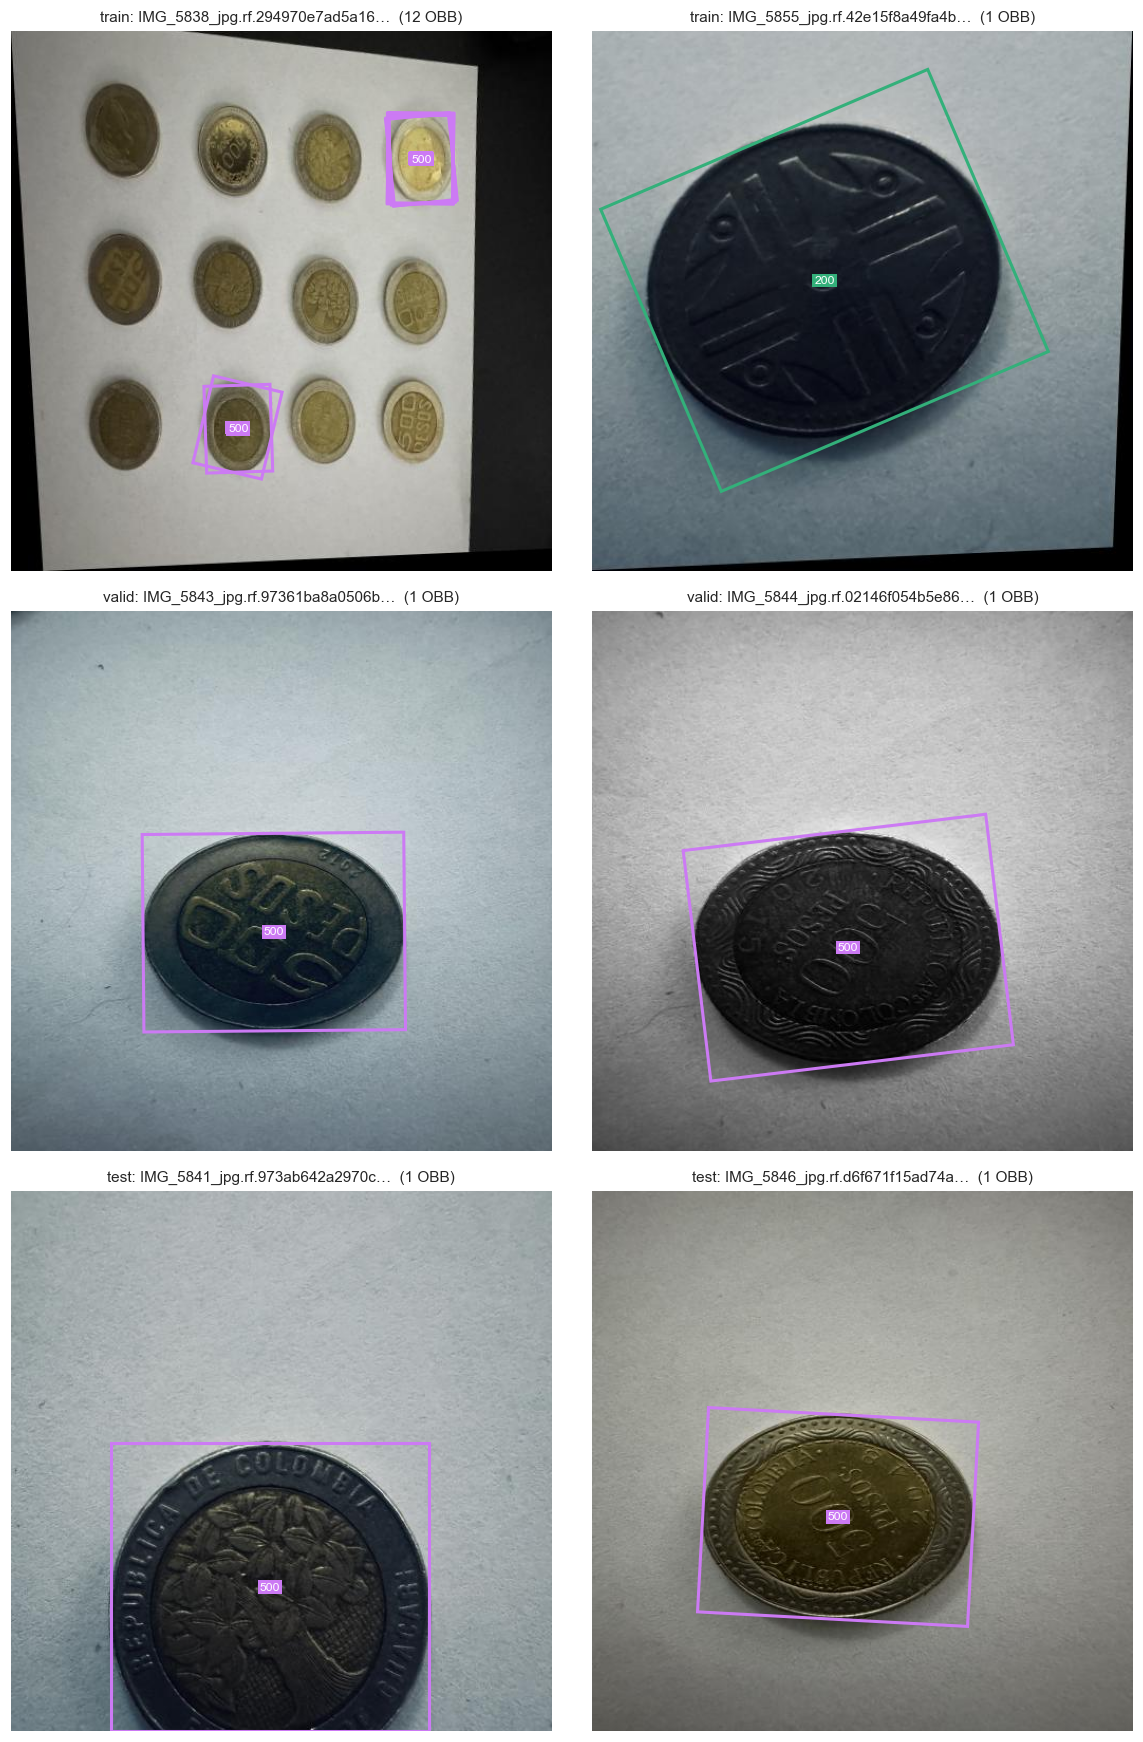

In [10]:
PALETTE = sns.color_palette("husl", NC)

def draw_obb(ax, img_path: Path, obbs: list[dict], title: str = ""):
    img = np.array(Image.open(img_path).convert("RGB"))
    H, W = img.shape[:2]
    ax.imshow(img)
    for b in obbs:
        v = b["vertices"] * np.array([W, H])
        color = PALETTE[b["class_id"] % NC]
        poly = patches.Polygon(v, closed=True, lw=2, edgecolor=color, facecolor="none")
        ax.add_patch(poly)
        cx, cy = v.mean(axis=0)
        ax.text(cx, cy, ID2NAME[b["class_id"]],
                color="white", fontsize=8, ha="center", va="center",
                bbox=dict(facecolor=color, edgecolor="none", pad=1.2))
    ax.set_title(title, fontsize=10); ax.axis("off")

fig, axes = plt.subplots(3, 2, figsize=(11, 16))
for row, split in enumerate(SPLITS):
    imgs = list_images(split)
    if not imgs:
        continue
    # Para train tomamos imágenes con muchas anotaciones; para valid/test, las disponibles
    counts = df[df["split"] == split].groupby("image_stem").size().sort_values(ascending=False)
    if len(counts) >= 2:
        picks_stems = list(counts.index[:1]) + [random.choice(list(counts.index[1:]))]
    else:
        picks_stems = list(counts.index) + [None]
    for col, stem in enumerate(picks_stems):
        ax = axes[row, col]
        if stem is None:
            ax.set_axis_off(); continue
        img_path = next((DATASET / split / "images").glob(f"{stem}.*"))
        obbs = parse_obb_file(DATASET / split / "labels" / (stem + ".txt"))
        draw_obb(ax, img_path, obbs,
                 title=f"{split}: {stem[:30]}…  ({len(obbs)} OBB)")
plt.tight_layout()
plt.savefig(REPORTS / "samples.png", dpi=130)
plt.show()

## 10. Análisis de color del dataset

Confirmamos que el dataset es a color (saturación HSV >> 0) y comparamos splits.

In [11]:
color_rows = []
for split in SPLITS:
    for p in list_images(split):
        im = np.array(Image.open(p).convert("HSV"))
        color_rows.append({
            "split": split,
            "name": p.name,
            "sat_mean": float(im[:, :, 1].mean()),
            "val_mean": float(im[:, :, 2].mean()),
        })
df_color = pd.DataFrame(color_rows)
df_color.to_csv(REPORTS / "image_color_stats.csv", index=False)
print(df_color.groupby("split")[["sat_mean", "val_mean"]].describe().round(1).T)

split            test  train  valid
sat_mean count    8.0  198.0    8.0
         mean    24.6   35.1   34.8
         std     13.6   20.3   21.3
         min      0.0    0.0    0.0
         25%     19.1   22.9   25.9
         50%     26.6   32.0   37.7
         75%     30.1   44.0   45.2
         max     47.1  105.8   69.5
val_mean count    8.0  198.0    8.0
         mean   142.2  130.9  140.9
         std     14.9   17.4    8.4
         min    130.0   97.3  132.1
         25%    133.7  117.7  136.2
         50%    137.0  130.1  137.7
         75%    142.4  141.1  143.5
         max    174.8  170.8  157.0


## 11. Persistencia de la tabla de anotaciones

In [12]:
df.to_csv(REPORTS / "annotations.csv", index=False)
print("Artefactos en reports/:")
for p in sorted(REPORTS.iterdir()):
    print("  -", p.name)

Artefactos en reports/:
  - annotations.csv
  - boxes_per_image_summary.csv
  - class_distribution.csv
  - class_distribution.png
  - image_color_stats.csv
  - inventory.csv
  - obb_geometry.png
  - samples.png


## 12. Hallazgos y recomendaciones para Fase 2 (entrenamiento)

Las celdas anteriores caracterizaron el dataset; los **hallazgos numéricos** quedan en los CSV de `reports/` y los gráficos en los PNG. Los **hallazgos cualitativos** que esperamos confirmar son:

1. **Imágenes a color** (saturación HSV >> 0) en los tres splits.
2. **Formato OBB**: 9 tokens por anotación; YOLOv8-detect requerirá conversión a AABB (axis-aligned bbox) antes de entrenar (o usar YOLOv8-OBB).
3. **Estiramiento (stretch) en el resize** declarado por Roboflow en el README. Verificable en el aspect ratio del OBB nativo: si las monedas reales son circulares y el resize es stretch, el ratio será sistemáticamente distinto de 1.
4. **Augmentations duplicadas:** Roboflow generó 9 versiones por imagen original → la diversidad real es ~24 imágenes únicas. Hay que verificar si los splits están dividiendo POR BASE o si hay leakage (variantes del mismo origen en distintos splits, lo que infla las métricas).
5. **Splits valid/test enanos** (1 anotación por imagen, 8 imágenes c/u). Como en versiones anteriores, el split heredado de Roboflow no es estadísticamente robusto y conviene re-particionar 80/10/10 estratificado por clase.

### Recomendaciones ya validadas para Fase 2
- **Convertir OBB → AABB** para entrenar `YOLOv8-detect`, que es el formato esperado por la app móvil (cajas axis-aligned).
- **Re-split estratificado 80/10/10** asegurando agrupamiento por imagen base (todas las variantes de `IMG_5XXX` van al MISMO split) para evitar data leakage.
- Si el OBB ratio confirma stretch, **revertir el stretch** con letterbox antes del re-split, o aceptar el stretch y replicarlo en la app móvil.
- Usar transfer learning desde `yolov8n.pt`, augmentations adicionales en entrenamiento (mosaic, mixup, hsv) y `imgsz=640`.